# Silver box position check via edge detection

Goal: detect the edges of the **large silver shiny metal box (tray)** in the bird's-eye overhead photo,
then tell whether the box has been put back in the **same position** as a reference photo — and if not,
**which way to nudge it** to line it back up.

Pipeline (fast, ~5-10 ms per image):
1. `find_box_edges(image)` -> finds the silver box outline (center, size, angle, 4 corners).
2. `plot_box_edges(image, edges)` -> draws that outline on the image so you can eyeball it.
3. `same_position(ref_edges, new_image)` -> True/False + direction to move the box back.

**Why this works:** the pegboard background is bright *but covered in a regular dot pattern*, while the
silver box interior is bright *and smooth*. We keep pixels that are bright AND locally smooth, then a
morphological OPEN erases the dotted pegboard (dots are small) but keeps the solid box interior.
No reliance on the box being green / a specific color, so it handles different boxes.

reference image: 2056 x 1542


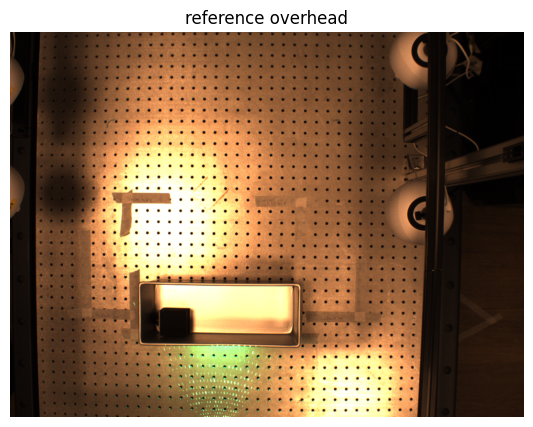

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---- config: point these at your images -------------------------------------
REF_PATH = r"D:\eturok\experiment-22\data\samples\000000\outputs\00_raw_overhead.png"

def load_bgr(path):
    """Load an image as OpenCV BGR (uint8)."""
    return cv2.cvtColor(np.asarray(Image.open(path).convert("RGB")), cv2.COLOR_RGB2BGR)

def show(bgr, title="", ax=None):
    """Display a BGR image inline."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title); ax.axis("off")
    return ax

ref = load_bgr(REF_PATH)
print("reference image:", ref.shape[1], "x", ref.shape[0])
show(ref, "reference overhead");

## 1. `find_box_edges` — detect the silver box outline

Returns a dict describing the box:
- `center` (cx, cy) in pixels
- `size` (width, height)
- `angle` degrees
- `corners` the 4 corner points (for plotting)

Everything runs on a downscaled copy (default 500 px wide) for speed, then scales the result back up.

In [2]:
def find_box_edges(bgr, work_w=500, bright_thresh=110, smooth_thresh=10.0,
                   open_px=13, close_px=21):
    """
    Find the large silver shiny box (smooth bright region) in a bird's-eye photo.

    Discriminator: box interior is bright AND smooth; pegboard is bright but textured
    (regular dots). We keep bright+smooth pixels, then OPEN to erase the small dots
    while the solid box survives, and fit a rotated rectangle to the largest blob.

    Returns dict(center, size, angle, corners, area) or None if nothing found.
    """
    H, W = bgr.shape[:2]
    s = work_w / W
    small = cv2.resize(bgr, (work_w, int(round(H * s))))
    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # local mean + std over a small window  ->  smoothness map
    k = 7
    m  = cv2.boxFilter(gray, -1, (k, k))
    sq = cv2.boxFilter(gray * gray, -1, (k, k))
    std = cv2.sqrt(np.maximum(sq - m * m, 0))

    mask = ((m > bright_thresh) & (std < smooth_thresh)).astype(np.uint8) * 255
    # OPEN kills the dotted pegboard (small features); CLOSE fills the box interior
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_px, open_px)))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_px, close_px)))

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    surf = max(cnts, key=cv2.contourArea)
    (cx, cy), (bw, bh), ang = cv2.minAreaRect(surf)

    # scale the rectangle back to full-resolution coordinates
    inv = 1.0 / s
    rect = ((cx * inv, cy * inv), (bw * inv, bh * inv), ang)
    corners = cv2.boxPoints(rect)
    return {
        "center": (rect[0][0], rect[0][1]),
        "size":   (rect[1][0], rect[1][1]),
        "angle":  ang,
        "corners": corners,
        "area":   rect[1][0] * rect[1][1],
    }

## 2. `plot_box_edges` — draw the detected outline

detect took 5.7 ms
center: (857.4, 1108.2)  size: (160.4, 489.3)  angle: 90.0


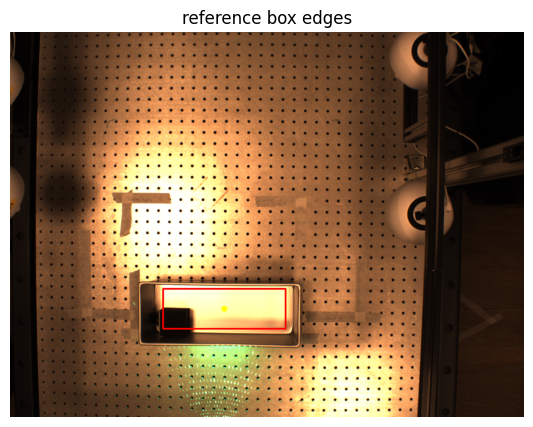

In [3]:
def plot_box_edges(bgr, edges, color=(0, 0, 255), thickness=6, ax=None, title="detected box"):
    """Draw the detected box outline + center dot on a copy of the image and show it."""
    vis = bgr.copy()
    if edges is not None:
        pts = edges["corners"].astype(np.int32)
        cv2.drawContours(vis, [pts], 0, color, thickness)
        c = tuple(int(v) for v in edges["center"])
        cv2.circle(vis, c, 12, (0, 255, 255), -1)
    return show(vis, title, ax=ax)

import time
t = time.time()
ref_edges = find_box_edges(ref)
dt = (time.time() - t) * 1000
print(f"detect took {dt:.1f} ms")
print("center:", tuple(round(v, 1) for v in ref_edges["center"]),
      " size:", tuple(round(v, 1) for v in ref_edges["size"]),
      " angle:", round(ref_edges["angle"], 1))
plot_box_edges(ref, ref_edges, title="reference box edges");

## 3. `same_position` — did the box move, and which way to fix it?

Compares a new image's box against the reference box. Not pixel-exact — it reports whether the box is
within a tolerance, and if not, **which direction to slide it** to line it back up.

- `dx, dy` = how far the box moved from the reference (pixels, image coords: +x right, +y down).
- The **instructions** tell you which way to physically move the box to return it to the reference spot.
- Also checks rotation (`d_angle`).

In [4]:
def _norm_angle(a):
    """minAreaRect angle is ambiguous by 90 deg; fold into [-45, 45)."""
    a = a % 90.0
    if a >= 45.0:
        a -= 90.0
    return a

def same_position(ref_edges, new_bgr, tol_px=25, tol_deg=5.0, **detect_kwargs):
    """
    Check whether the box in `new_bgr` is in the same spot as `ref_edges`.

    Returns a dict:
      in_place   : bool  (within tol_px and tol_deg)
      dx, dy     : how far the box moved (px) from reference (+x right, +y down)
      distance   : euclidean shift in px
      d_angle    : rotation change (deg)
      instructions : human-readable how to move the box back
    """
    new_edges = find_box_edges(new_bgr, **detect_kwargs)
    if new_edges is None:
        return {"in_place": False, "instructions": ["box not found in new image"],
                "dx": None, "dy": None, "distance": None, "d_angle": None,
                "new_edges": None}

    rcx, rcy = ref_edges["center"]
    ncx, ncy = new_edges["center"]
    dx, dy = ncx - rcx, ncy - rcy                     # how far the box moved
    dist = float(np.hypot(dx, dy))
    d_ang = _norm_angle(new_edges["angle"] - ref_edges["angle"])

    moved = dist > tol_px
    rotated = abs(d_ang) > tol_deg
    in_place = not (moved or rotated)

    # instructions: move the box the OPPOSITE way it drifted, to restore reference
    instr = []
    if moved:
        if abs(dx) > tol_px / 2:
            instr.append(f"move {'LEFT' if dx > 0 else 'RIGHT'} {abs(dx):.0f}px")
        if abs(dy) > tol_px / 2:
            instr.append(f"move {'UP' if dy > 0 else 'DOWN'} {abs(dy):.0f}px")
    if rotated:
        instr.append(f"rotate {'CCW' if d_ang > 0 else 'CW'} {abs(d_ang):.1f} deg")
    if in_place:
        instr = ["in place - no adjustment needed"]

    return {"in_place": in_place, "dx": dx, "dy": dy, "distance": dist,
            "d_angle": d_ang, "instructions": instr, "new_edges": new_edges}

## 4. Test it

The physical tray is fixed across the dataset samples, so to *exercise* the "moved" case we synthesize a
version of the reference where the box is deliberately shifted and rotated (`warpAffine`). We then confirm:
- an unshifted copy reads as **in place**,
- the shifted copy is flagged with the correct **direction to move it back**.

A) unchanged  : True | ['in place - no adjustment needed']
B) moved+rot  : False | ['move LEFT 145px', 'move UP 80px'] (dx=145, dy=80, dang=-3.4)


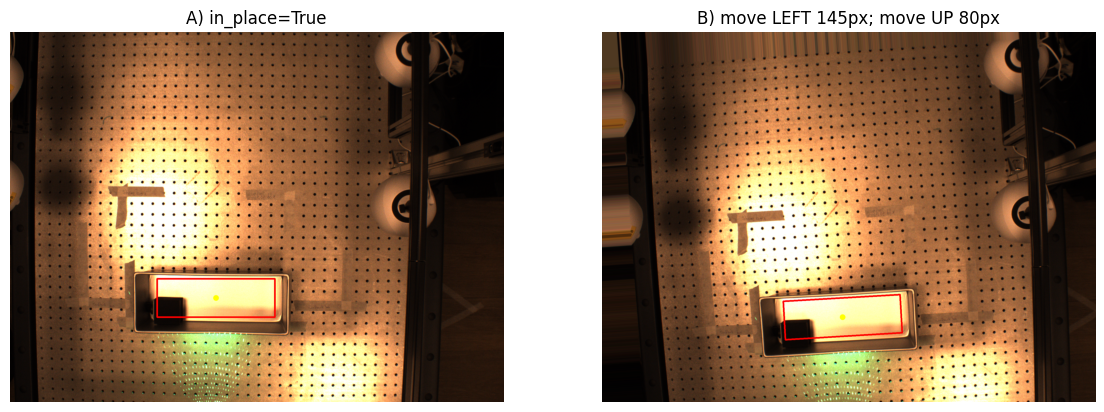

In [5]:
def shift_rotate(bgr, dx, dy, deg):
    """Make a test image with the whole scene translated by (dx,dy) and rotated by deg."""
    H, W = bgr.shape[:2]
    M = cv2.getRotationMatrix2D((W / 2, H / 2), deg, 1.0)
    M[0, 2] += dx
    M[1, 2] += dy
    return cv2.warpAffine(bgr, M, (W, H), borderMode=cv2.BORDER_REPLICATE)

# case A: same image -> should be in place
same_img = ref.copy()
resA = same_position(ref_edges, same_img)
print("A) unchanged  :", resA["in_place"], "|", resA["instructions"])

# case B: box shifted right + down and rotated -> should say move left + up, rotate back
moved_img = shift_rotate(ref, dx=120, dy=70, deg=4)
resB = same_position(ref_edges, moved_img)
print("B) moved+rot  :", resB["in_place"], "|", resB["instructions"],
      f"(dx={resB['dx']:.0f}, dy={resB['dy']:.0f}, dang={resB['d_angle']:.1f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_box_edges(same_img, resA["new_edges"], ax=axes[0], title=f"A) in_place={resA['in_place']}")
plot_box_edges(moved_img, resB["new_edges"], ax=axes[1],
               title="B) " + "; ".join(resB["instructions"]));

## 5. End-goal wrapper

One call that takes two image paths and tells you if the box is back in place and how to fix it.

In [6]:
def is_box_in_place(ref_path, new_path, tol_px=25, tol_deg=5.0):
    """Top-level check: is the box in `new_path` in the same spot as in `ref_path`?"""
    ref_img = load_bgr(ref_path)
    new_img = load_bgr(new_path)
    ref_e = find_box_edges(ref_img)
    res = same_position(ref_e, new_img, tol_px=tol_px, tol_deg=tol_deg)
    print(("OK - box in place" if res["in_place"] else "MOVED -> " + "; ".join(res["instructions"])))
    return res

# example: compare the reference against another sample (physically the same tray -> in place)
_ = is_box_in_place(
    REF_PATH,
    r"D:\eturok\experiment-22\data\samples\000024\outputs\00_raw_overhead.png",
)

OK - box in place
